# Event/raster analysis of *Neohelice granulata* behavioral responses

This notebook contains the Python analysis used in the C.R.A.B. project for event/raster-style analysis of crab responses to mechanical stimulation. It is part of an experimental study carried out at IFIBYNE (CONICET–UBA) during Laboratorio 6, FCEyN–UBA (2025).

## Objective

Process and visualize experimental behavioral-response records generated during the C.R.A.B. study.

> **Data note:** the original experimental files are not included automatically in this repository. File references have been made repository-relative where possible; place the corresponding data files in a `data/` directory when reproducing the analysis.

## Workflow

1. Import the required Python libraries.
2. Load and organize experimental response records.
3. Transform the records for event/raster-style representation.
4. Generate visualizations used to compare responses across stimulation periods.


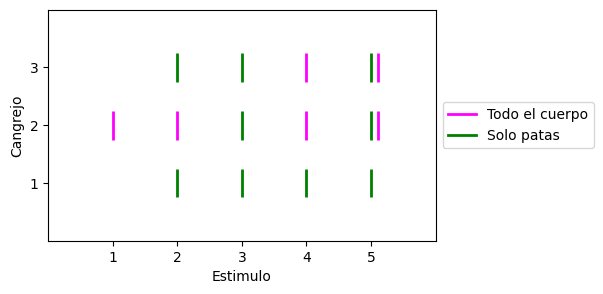

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
patas = 'green'
todo = 'magenta'

# Datos:
np.random.seed(1)
x = [1, 2, 3]
D_patas = [[2,3,4,5],[3,5],[2,3,5]]
D_todo = [[],[1,2,4],[4]]


P_patas = [[],[],[]]
P_todo = [[],[5.1],[5.1]]
# Plot:
fig, ax = plt.subplots(figsize=(5,3))

# Graficar sin labels repetidos
ax.eventplot(D_patas, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
ax.eventplot(P_patas, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)

ax.eventplot(D_todo, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
ax.eventplot(P_todo, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)

# Crear leyenda manual con rojo las patas, con azul todo el cuerpo
legend_elements = [
    Line2D([0], [0], color=todo, lw=2, label='Todo el cuerpo'),
    Line2D([0], [0], color=patas, lw=2, label='Solo patas')
]
ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))

# Ejes y etiquetas
ax.set(xlim=(0, 6), xticks=np.arange(1, 6),
       ylim=(0, 4), yticks=np.arange(1, 4))
ax.set_ylabel('Cangrejo', fontsize=10)
ax.set_xlabel('Estimulo', fontsize=10)

plt.show()



##Prueba 1 sin agua, brazo en el extremo, pertubacion continua


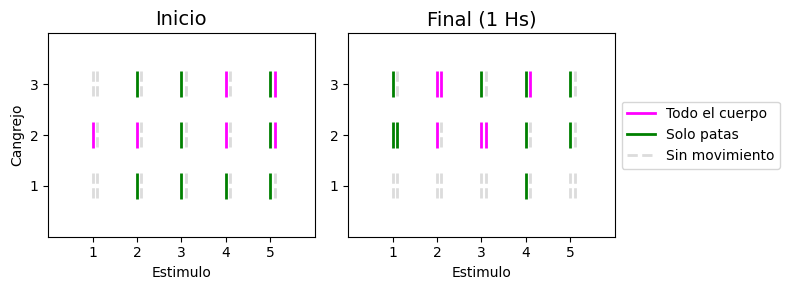

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

patas = 'green'
todo = 'magenta'
hueco = 'gainsboro'

# Datos:
x = [1, 2, 3]
# Tiempo total (estimulo) en pasos de 1.0 y 0.1
tiempos_posibles = [1, 1.1, 2, 2.1, 3, 3.1, 4, 4.1, 5, 5.1]

D_patas_1 = [[2, 3, 4, 5], [3, 5], [2, 3, 5]]
D_todo_1  = [[], [1, 2, 4], [4]]
P_patas_1 = [[], [], []]
P_todo_1  = [[], [5.1], [5.1]]

D_patas_2 = [[4], [1,4,5], [1,3,4,5]]
D_todo_2  = [[], [2,3], [2]]
P_patas_2 = [[], [1.1], []]
P_todo_2  = [[], [3.1], [2.1,4.1]]


# Construir eventos totales por cangrejo
eventos_1 = []
for i in range(3):
    todos_eventos_1 = set(D_patas_1[i] + D_todo_1[i] + P_patas_1[i] + P_todo_1[i])
    vacios_1 = [t for t in tiempos_posibles if t not in todos_eventos_1]
    eventos_1.append(vacios_1)

eventos_2 = []
for i in range(3):
    todos_eventos_2 = set(D_patas_2[i] + D_todo_2[i] + P_patas_2[i] + P_todo_2[i])
    vacios_2 = [t for t in tiempos_posibles if t not in todos_eventos_2]
    eventos_2.append(vacios_2)



# Plot:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

# Eventos reales inicio
axs[0].eventplot(D_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(P_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(D_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[0].eventplot(P_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)


# Eventos reales final
axs[1].eventplot(D_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(P_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(D_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[1].eventplot(P_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)



# Eventos vacíos (huecos)
axs[0].eventplot(eventos_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
# Eventos vacíos (huecos)
axs[1].eventplot(eventos_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')


# Leyenda
legend_elements = [
    Line2D([0], [0], color=todo, lw=2, label='Todo el cuerpo'),
    Line2D([0], [0], color=patas, lw=2, label='Solo patas'),
    Line2D([0], [0],ls='--', color=hueco, lw=2, label='Sin movimiento')
]


#axs[0].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
axs[1].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))

# Ejes
axs[0].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[0].set_ylabel('Cangrejo', fontsize=10)
axs[0].set_xlabel('Estimulo', fontsize=10)
axs[0].set_title('Inicio', fontsize=14)

axs[1].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[1].set_ylabel('Cangrejo', fontsize=10)
axs[1].set_xlabel('Estimulo', fontsize=10)
axs[1].set_title('Final (1 Hs)', fontsize=14)

plt.tight_layout()
plt.show()


##Prueba 2, 1 cm agua, brazo en el eje, pertubacion en tandas

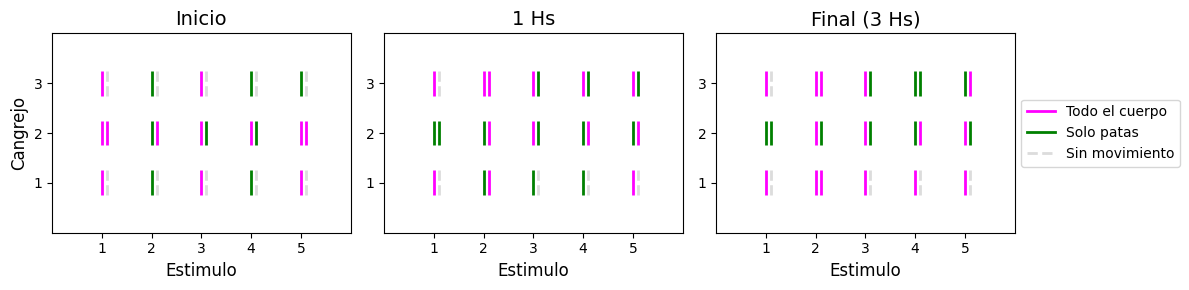

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

patas = 'green'
todo = 'magenta'
hueco = 'gainsboro'

# Datos:
x = [1, 2, 3]
# Tiempo total (estimulo) en pasos de 1.0 y 0.1
tiempos_posibles = [1, 1.1, 2, 2.1, 3, 3.1, 4, 4.1, 5, 5.1]

D_patas_1 = [[2,4], [2], [2,4,5]]
D_todo_1  = [[1,3,5], [1,3,4,5], [1,3]]
P_patas_1 = [[], [3.1,4.1], []]
P_todo_1  = [[], [1.1,2.1,5.1], []]

D_patas_2 = [[2,3,4], [1,2,4,5], []]
D_todo_2  = [[1,5], [3], [1,2,3,4,5]]
P_patas_2 = [[], [1.1,3.1], [3.1,4.1,5.1]]
P_todo_2  = [[2.1], [2.1,4.1,5.1], [2.1]]

D_patas_3 = [[], [1,4], [4,5]]
D_todo_3  = [[1,2,3,4,5], [2,3,5], [1,2,3]]
P_patas_3 = [[], [1.1,2.1,3.1,5.1], [3.1,4.1]]
P_todo_3  = [[2.1], [4.1], [2.1,5.1]]


# Construir eventos totales por cangrejo
eventos_1 = []
for i in range(3):
    todos_eventos_1 = set(D_patas_1[i] + D_todo_1[i] + P_patas_1[i] + P_todo_1[i])
    vacios_1 = [t for t in tiempos_posibles if t not in todos_eventos_1]
    eventos_1.append(vacios_1)

eventos_2 = []
for i in range(3):
    todos_eventos_2 = set(D_patas_2[i] + D_todo_2[i] + P_patas_2[i] + P_todo_2[i])
    vacios_2 = [t for t in tiempos_posibles if t not in todos_eventos_2]
    eventos_2.append(vacios_2)

eventos_3 = []
for i in range(3):
    todos_eventos_3 = set(D_patas_3[i] + D_todo_3[i] + P_patas_3[i] + P_todo_3[i])
    vacios_3 = [t for t in tiempos_posibles if t not in todos_eventos_3]
    eventos_3.append(vacios_3)

# Plot:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))

# Eventos reales inicio
axs[0].eventplot(D_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(P_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(D_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[0].eventplot(P_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)


# Eventos reales final
axs[1].eventplot(D_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(P_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(D_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[1].eventplot(P_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)

axs[2].eventplot(D_patas_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[2].eventplot(P_patas_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[2].eventplot(D_todo_3,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[2].eventplot(P_todo_3,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)

# Eventos vacíos (huecos)
axs[0].eventplot(eventos_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
# Eventos vacíos (huecos)
axs[1].eventplot(eventos_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
axs[2].eventplot(eventos_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')

# Leyenda
legend_elements = [
    Line2D([0], [0], color=todo, lw=2, label='Todo el cuerpo'),
    Line2D([0], [0], color=patas, lw=2, label='Solo patas'),
    Line2D([0], [0],ls='--', color=hueco, lw=2, label='Sin movimiento')
]


#axs[0].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
axs[2].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))

# Ejes
axs[0].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[0].set_ylabel('Cangrejo', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('Inicio', fontsize=14)

axs[1].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[1].set_ylabel('Cangrejo', fontsize=10)
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('1 Hs', fontsize=14)

axs[2].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[2].set_ylabel('Cangrejo', fontsize=10)
axs[2].set_xlabel('Estimulo', fontsize=12)
axs[2].set_title('Final (3 Hs)', fontsize=14)

plt.tight_layout()
plt.show()


##prueba 3 100 ml agua 1 hs brazo en el eje

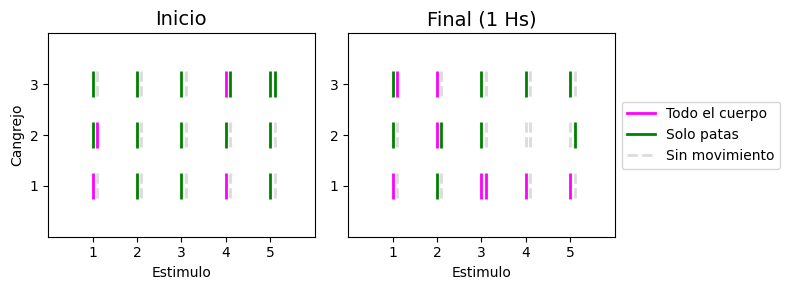

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

patas = 'green'
todo = 'magenta'
hueco = 'gainsboro'

# Datos:
x = [1, 2, 3]
# Tiempo total (estimulo) en pasos de 1.0 y 0.1
tiempos_posibles = [1, 1.1, 2, 2.1, 3, 3.1, 4, 4.1, 5, 5.1]

D_patas_1 = [[2,3,5], [1,2,3,4,5], [1,2,3,5]]
D_todo_1  = [[1,4], [], [4]]
P_patas_1 = [[], [], [4.1,5.1]]
P_todo_1  = [[], [1.1], []]

D_patas_2 = [[2], [1,3], [1,3,4,5]]
D_todo_2  = [[1,3,4,5], [2], [2]]
P_patas_2 = [[], [2.1,5.1], []]
P_todo_2  = [[3.1], [], [1.1]]


# Construir eventos totales por cangrejo
eventos_1 = []
for i in range(3):
    todos_eventos_1 = set(D_patas_1[i] + D_todo_1[i] + P_patas_1[i] + P_todo_1[i])
    vacios_1 = [t for t in tiempos_posibles if t not in todos_eventos_1]
    eventos_1.append(vacios_1)

eventos_2 = []
for i in range(3):
    todos_eventos_2 = set(D_patas_2[i] + D_todo_2[i] + P_patas_2[i] + P_todo_2[i])
    vacios_2 = [t for t in tiempos_posibles if t not in todos_eventos_2]
    eventos_2.append(vacios_2)



# Plot:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

# Eventos reales inicio
axs[0].eventplot(D_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(P_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(D_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[0].eventplot(P_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)


# Eventos reales final
axs[1].eventplot(D_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(P_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(D_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[1].eventplot(P_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)



# Eventos vacíos (huecos)
axs[0].eventplot(eventos_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
# Eventos vacíos (huecos)
axs[1].eventplot(eventos_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')


# Leyenda
legend_elements = [
    Line2D([0], [0], color=todo, lw=2, label='Todo el cuerpo'),
    Line2D([0], [0], color=patas, lw=2, label='Solo patas'),
    Line2D([0], [0],ls='--', color=hueco, lw=2, label='Sin movimiento')
]


#axs[0].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
axs[1].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))

# Ejes
axs[0].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[0].set_ylabel('Cangrejo', fontsize=10)
axs[0].set_xlabel('Estimulo', fontsize=10)
axs[0].set_title('Inicio', fontsize=14)

axs[1].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[1].set_ylabel('Cangrejo', fontsize=10)
axs[1].set_xlabel('Estimulo', fontsize=10)
axs[1].set_title('Final (1 Hs)', fontsize=14)

plt.tight_layout()
plt.show()


##Prueba 4 100 ml agua bla bla

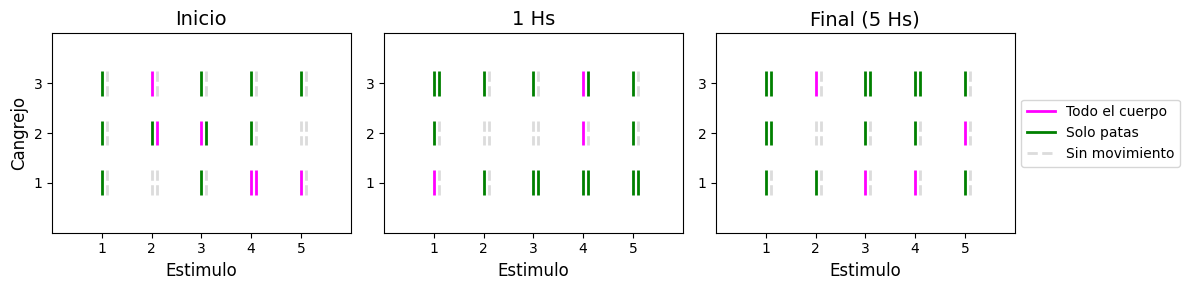

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

patas = 'green'
todo = 'magenta'
hueco = 'gainsboro'

# Datos:
x = [1, 2, 3]
# Tiempo total (estimulo) en pasos de 1.0 y 0.1
tiempos_posibles = [1, 1.1, 2, 2.1, 3, 3.1, 4, 4.1, 5, 5.1]

D_patas_1 = [[1,3], [1,2,4], [1,3,4,5]]
D_todo_1  = [[4,5], [3], [2]]
P_patas_1 = [[], [3.1], []]
P_todo_1  = [[4.1], [2.1], []]

D_patas_2 = [[2,3,4,5], [1,5], [1,2,3,5]]
D_todo_2  = [[1], [4], [4]]
P_patas_2 = [[3.1,4.1,5.1], [], [1.1,4.1]]
P_todo_2  = [[], [], []]

D_patas_3 = [[1,2,5], [1,3,4], [1,3,4,5]]
D_todo_3  = [[3,4], [5], [2]]
P_patas_3 = [[], [1.1], [1.1,3.1,4.1]]
P_todo_3  = [[], [], []]

# Construir eventos totales por cangrejo
eventos_1 = []
for i in range(3):
    todos_eventos_1 = set(D_patas_1[i] + D_todo_1[i] + P_patas_1[i] + P_todo_1[i])
    vacios_1 = [t for t in tiempos_posibles if t not in todos_eventos_1]
    eventos_1.append(vacios_1)

eventos_2 = []
for i in range(3):
    todos_eventos_2 = set(D_patas_2[i] + D_todo_2[i] + P_patas_2[i] + P_todo_2[i])
    vacios_2 = [t for t in tiempos_posibles if t not in todos_eventos_2]
    eventos_2.append(vacios_2)

eventos_3 = []
for i in range(3):
    todos_eventos_3 = set(D_patas_3[i] + D_todo_3[i] + P_patas_3[i] + P_todo_3[i])
    vacios_3 = [t for t in tiempos_posibles if t not in todos_eventos_3]
    eventos_3.append(vacios_3)

# Plot:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))

# Eventos reales inicio
axs[0].eventplot(D_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(P_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(D_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[0].eventplot(P_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)


# Eventos reales final
axs[1].eventplot(D_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(P_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(D_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[1].eventplot(P_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)

axs[2].eventplot(D_patas_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[2].eventplot(P_patas_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[2].eventplot(D_todo_3,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[2].eventplot(P_todo_3,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)


# Eventos vacíos (huecos)
axs[0].eventplot(eventos_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
# Eventos vacíos (huecos)
axs[1].eventplot(eventos_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
axs[2].eventplot(eventos_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')

# Leyenda
legend_elements = [
    Line2D([0], [0], color=todo, lw=2, label='Todo el cuerpo'),
    Line2D([0], [0], color=patas, lw=2, label='Solo patas'),
    Line2D([0], [0],ls='--', color=hueco, lw=2, label='Sin movimiento')
]


#axs[0].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
axs[2].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))


# Ejes
axs[0].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[0].set_ylabel('Cangrejo', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('Inicio', fontsize=14)

axs[1].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[1].set_ylabel('Cangrejo', fontsize=10)
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('1 Hs', fontsize=14)

axs[2].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[2].set_ylabel('Cangrejo', fontsize=10)
axs[2].set_xlabel('Estimulo', fontsize=12)
axs[2].set_title('Final (5 Hs)', fontsize=14)


plt.tight_layout()
plt.show()


##Video 6 horaaas

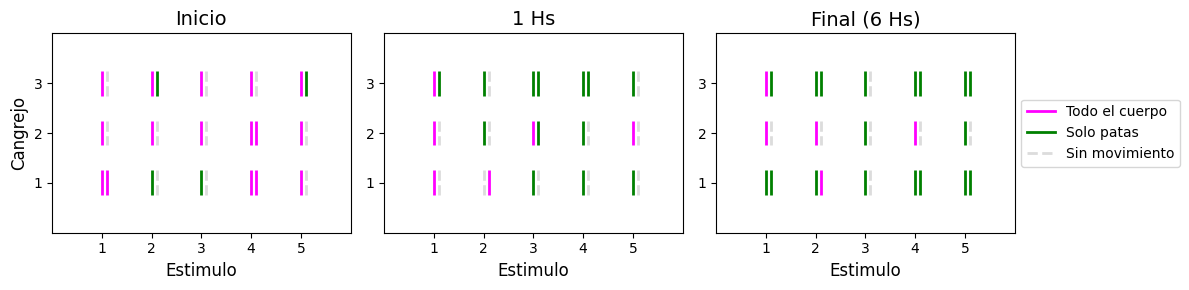

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

patas = 'green'
todo = 'magenta'
hueco = 'gainsboro'

# Datos:
x = [1, 2, 3]
# Tiempo total (estimulo) en pasos de 1.0 y 0.1
tiempos_posibles = [1, 1.1, 2, 2.1, 3, 3.1, 4, 4.1, 5, 5.1]

D_patas_1 = [[2,3], [], []]
D_todo_1  = [[1,4,5], [1,2,3,4,5], [1,2,3,4,5]]
P_patas_1 = [[], [], [2.1,5.1]]
P_todo_1  = [[1.1,4.1], [4.1], []]

D_patas_2 = [[3,4,5], [2,4], [2,3,4,5]]
D_todo_2  = [[1], [1,3,5], [1]]
P_patas_2 = [[], [3.1], [1.1,3.1,4.1]]
P_todo_2  = [[2.1], [], []]

D_patas_3 = [[1,2,3,4,5], [3,5], [2,3,4,5]]
D_todo_3  = [[], [1,2,4], [1]]
P_patas_3 = [[1.1,4.1,5.1], [], [1.1,2.1,4.1,5.1]]
P_todo_3  = [[2.1], [], []]


# Construir eventos totales por cangrejo
eventos_1 = []
for i in range(3):
    todos_eventos_1 = set(D_patas_1[i] + D_todo_1[i] + P_patas_1[i] + P_todo_1[i])
    vacios_1 = [t for t in tiempos_posibles if t not in todos_eventos_1]
    eventos_1.append(vacios_1)

eventos_2 = []
for i in range(3):
    todos_eventos_2 = set(D_patas_2[i] + D_todo_2[i] + P_patas_2[i] + P_todo_2[i])
    vacios_2 = [t for t in tiempos_posibles if t not in todos_eventos_2]
    eventos_2.append(vacios_2)

eventos_3 = []
for i in range(3):
    todos_eventos_3 = set(D_patas_3[i] + D_todo_3[i] + P_patas_3[i] + P_todo_3[i])
    vacios_3 = [t for t in tiempos_posibles if t not in todos_eventos_3]
    eventos_3.append(vacios_3)

# Plot:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))

# Eventos reales inicio
axs[0].eventplot(D_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(P_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(D_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[0].eventplot(P_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)


# Eventos reales final
axs[1].eventplot(D_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(P_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(D_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[1].eventplot(P_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)

axs[2].eventplot(D_patas_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[2].eventplot(P_patas_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[2].eventplot(D_todo_3,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[2].eventplot(P_todo_3,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)

# Eventos vacíos (huecos)
axs[0].eventplot(eventos_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
# Eventos vacíos (huecos)
axs[1].eventplot(eventos_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
axs[2].eventplot(eventos_3, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')

# Leyenda
legend_elements = [
    Line2D([0], [0], color=todo, lw=2, label='Todo el cuerpo'),
    Line2D([0], [0], color=patas, lw=2, label='Solo patas'),
    Line2D([0], [0],ls='--', color=hueco, lw=2, label='Sin movimiento')
]


#axs[0].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
axs[2].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))

# Ejes
axs[0].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[0].set_ylabel('Cangrejo', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('Inicio', fontsize=14)

axs[1].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[1].set_ylabel('Cangrejo', fontsize=10)
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('1 Hs', fontsize=14)

axs[2].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[2].set_ylabel('Cangrejo', fontsize=10)
axs[2].set_xlabel('Estimulo', fontsize=12)
axs[2].set_title('Final (6 Hs)', fontsize=14)

plt.tight_layout()
plt.show()

##Refernciaaaaaaaa :P

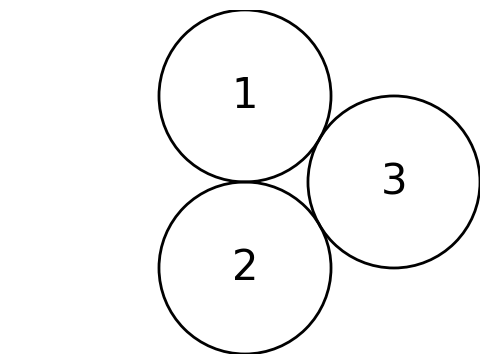

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Lado del triángulo
lado = 2
altura = np.sqrt(3) * lado / 2

# Coordenadas originales (antes de rotar)
centros_originales = np.array([
    (0, 0),                  # Círculo 1
    (lado, 0),               # Círculo 2
    (lado/2, altura)         # Círculo 3
])

# Rotar 90 grados en sentido horario: (x, y) -> (y, -x)
centros_rotados = np.array([(y, -x) for x, y in centros_originales])

# Crear figura
fig, ax = plt.subplots(figsize=(5, 5))

# Dibujar círculos rotados y numerarlos
for i, (x, y) in enumerate(centros_rotados):
    circulo = plt.Circle((x, y), radius=1, edgecolor='black', facecolor='none', linewidth=2)
    ax.add_patch(circulo)
    ax.text(x, y, str(i+1), fontsize=30, ha='center', va='center')

# Ajustar los ejes
ax.set_aspect('equal')
ax.set_xlim(-altura - 1, altura + 1)
ax.set_ylim(-lado - 1, 1)
ax.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

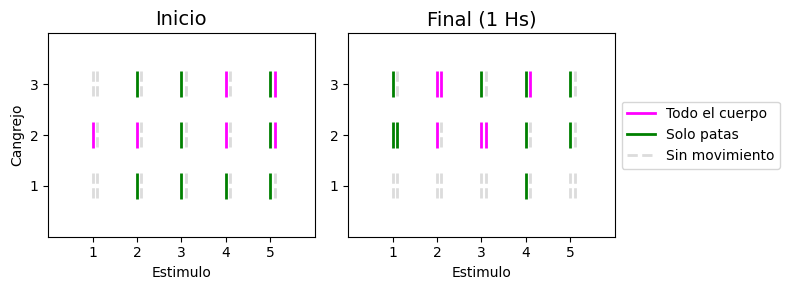

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

patas = 'green'
todo = 'magenta'
hueco = 'gainsboro'

# Datos:
x = [1, 2, 3]
# Tiempo total (estimulo) en pasos de 1.0 y 0.1
tiempos_posibles = [1, 1.1, 2, 2.1, 3, 3.1, 4, 4.1, 5, 5.1]

D_patas_1 = [[2, 3, 4, 5], [3, 5], [2, 3, 5]]
D_todo_1  = [[], [1, 2, 4], [4]]
P_patas_1 = [[], [], []]
P_todo_1  = [[], [5.1], [5.1]]

D_patas_2 = [[4], [1,4,5], [1,3,4,5]]
D_todo_2  = [[], [2,3], [2]]
P_patas_2 = [[], [1.1], []]
P_todo_2  = [[], [3.1], [2.1,4.1]]


# Construir eventos totales por cangrejo
eventos_1 = []
for i in range(3):
    todos_eventos_1 = set(D_patas_1[i] + D_todo_1[i] + P_patas_1[i] + P_todo_1[i])
    vacios_1 = [t for t in tiempos_posibles if t not in todos_eventos_1]
    eventos_1.append(vacios_1)

eventos_2 = []
for i in range(3):
    todos_eventos_2 = set(D_patas_2[i] + D_todo_2[i] + P_patas_2[i] + P_todo_2[i])
    vacios_2 = [t for t in tiempos_posibles if t not in todos_eventos_2]
    eventos_2.append(vacios_2)



# Plot:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(8, 3))

# Eventos reales inicio
axs[0].eventplot(D_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(P_patas_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[0].eventplot(D_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[0].eventplot(P_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)


# Eventos reales final
axs[1].eventplot(D_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(P_patas_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=patas)
axs[1].eventplot(D_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)
axs[1].eventplot(P_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=todo)



# Eventos vacíos (huecos)
axs[0].eventplot(eventos_1, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')
# Eventos vacíos (huecos)
axs[1].eventplot(eventos_2, orientation="horizontal", lineoffsets=x, linelengths=0.5, linewidth=2, color=hueco,linestyles='--')


# Leyenda
legend_elements = [
    Line2D([0], [0], color=todo, lw=2, label='Todo el cuerpo'),
    Line2D([0], [0], color=patas, lw=2, label='Solo patas'),
    Line2D([0], [0],ls='--', color=hueco, lw=2, label='Sin movimiento')
]


#axs[0].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
axs[1].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))

# Ejes
axs[0].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[0].set_ylabel('Cangrejo', fontsize=10)
axs[0].set_xlabel('Estimulo', fontsize=10)
axs[0].set_title('Inicio', fontsize=14)

axs[1].set(xlim=(0, 6), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
#axs[1].set_ylabel('Cangrejo', fontsize=10)
axs[1].set_xlabel('Estimulo', fontsize=10)
axs[1].set_title('Final (1 Hs)', fontsize=14)

plt.tight_layout()
plt.show()


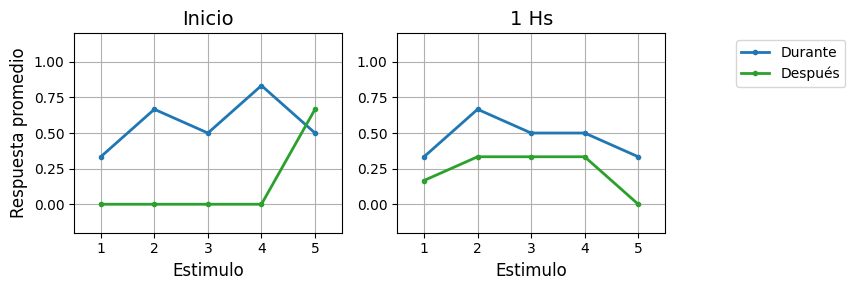

In [ ]:
##estimulo constante
#a la respuesta nula se le asocio un 0
#al movimiento de las patas un 0.5
#al movimiento del cuerpo completo un 1
# y en cada estimulo se ralizó el promedio de las respuestas de los tres cangrejos diferenciando entre
#respuesta durante y respuesta luego del estimulo.
estimulo = [1,2,3,4,5]
durante_inicio = np.array([1,2,1.5,2.5,1.5])
durante_final = np.array([1,2,1.5,1.5,1])
post_inicio = np.array([0,0,0,0,2])
post_final = np.array([0.5,1,1,1,0])

d_i = durante_inicio/3
d_f = durante_final/3
p_i = post_inicio/3
p_f = post_final/3

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(9, 3))

# Eventos  inicio
axs[0].plot(estimulo,d_i,'.-',lw=2, color='C0')
axs[0].plot(estimulo,p_i,'.-',lw=2, color='C2')
# Eventos  final
axs[1].plot(estimulo,d_f,'.-',lw=2, color='C0',label='Durante')
axs[1].plot(estimulo,p_f,'.-',lw=2, color='C2',label='Después')



axs[1].legend(bbox_to_anchor=(1.7, 1))

# Ejes
axs[0].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,5))
axs[0].set_ylabel('Respuesta promedio', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('Inicio', fontsize=14)
axs[0].grid()

axs[1].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,5))
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('1 Hs', fontsize=14)
axs[1].grid()


plt.tight_layout()
plt.show()

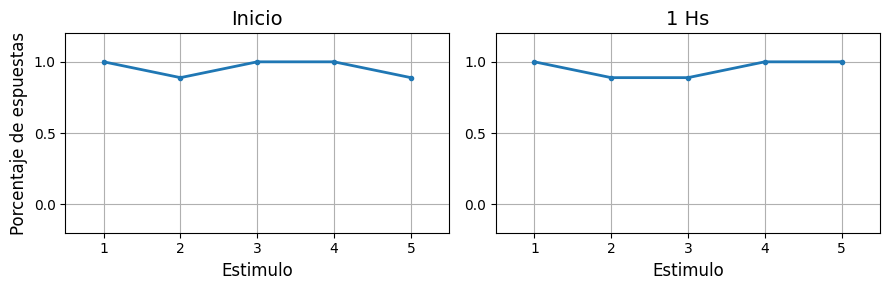

In [ ]:
#Para los estimulos intermitenes se hizo el promedio sobre los 3 cangrejos y las tres peubas al inicio y a la hora
#siendo en total 9 mediciones promeidadas

estimulo = [1,2,3,4,5]
durante_inicio = np.array([9,8,9,9,8])
durante_final = np.array([9,8,8,9,9])
post_inicio = np.array([2,3,2,4,2])
post_final = np.array([3,4,5,5,3])

d_i = durante_inicio/9
d_f = durante_final/9
p_i = post_inicio/9
p_f = post_final/9

fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(9, 3))

# Eventos inicio
axs[0].plot(estimulo,d_i,'.-',lw=2, color='C0')
#axs[0].plot(estimulo,p_i,'.-',lw=2, color='C2')
# Eventos final
axs[1].plot(estimulo,d_f,'.-',lw=2, color='C0',label='Durante')

#axs[1].plot(estimulo,p_f,'.-',lw=2, color='C2',label='Después')



#axs[1].legend(bbox_to_anchor=(1.7, 1))

# Ejes
axs[0].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,3))
axs[0].set_ylabel('Porcentaje de espuestas', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('Inicio', fontsize=14)
axs[0].grid()

axs[1].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,3))
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('1 Hs', fontsize=14)
axs[1].grid()


plt.tight_layout()
plt.show()

/tmp/ipython-input-57-4190935635.py:48: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


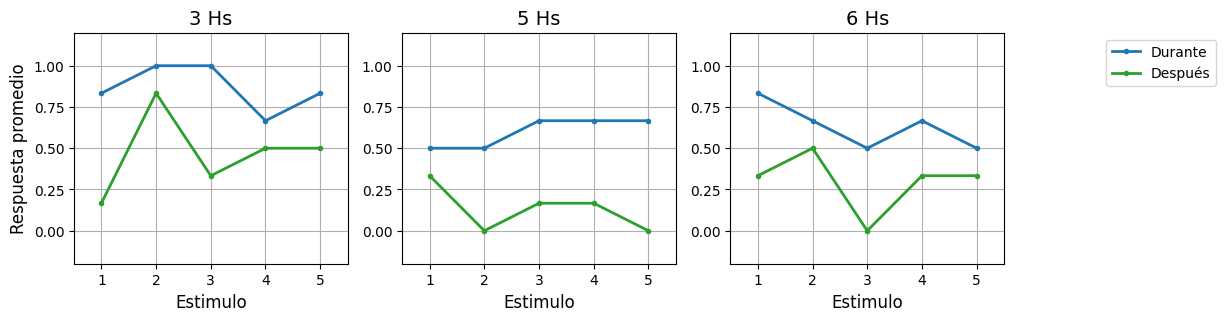

In [ ]:

estimulo = [1,2,3,4,5]
durante_3 = np.array([2.5,3,3,2,2.5])
durante_5 = np.array([1.5,1.5,2,2,2])
durante_6 = np.array([2.5,2,1.5,2,1.5])
post_3 = np.array([0.5,2.5,1,1.5,1.5])
post_5 = np.array([1,0,0.5,0.5,0])
post_6 = np.array([1,1.5,0,1,1])

d_3 = durante_3/3
d_5 = durante_5/3
d_6 = durante_6/3
p_3 = post_3/3
p_5 = post_5/3
p_6 = post_6/3


fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))

# Eventos 3hs
axs[0].plot(estimulo,d_3,'.-',lw=2, color='C0')
#axs[0].plot(estimulo,p_3,'.-',lw=2, color='C2')
# Eventos 5hs
axs[1].plot(estimulo,d_5,'.-',lw=2, color='C0',label='Durante')
#axs[1].plot(estimulo,p_5,'.-',lw=2, color='C2',label='Después')
#eventos 6hs
axs[2].plot(estimulo,d_6,'.-',lw=2, color='C0')
#axs[2].plot(estimulo,p_6,'.-',lw=2, color='C2')

axs[1].legend(bbox_to_anchor=(3, 1))

# Ejes
axs[0].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,5))
axs[0].set_ylabel('Respuesta promedio', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('3 Hs', fontsize=14)
axs[0].grid()

axs[1].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,5))
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('5 Hs', fontsize=14)
axs[1].grid()

axs[2].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,5))
axs[2].set_xlabel('Estimulo', fontsize=12)
axs[2].set_title('6 Hs', fontsize=14)
axs[2].grid()

plt.tight_layout()
plt.show()

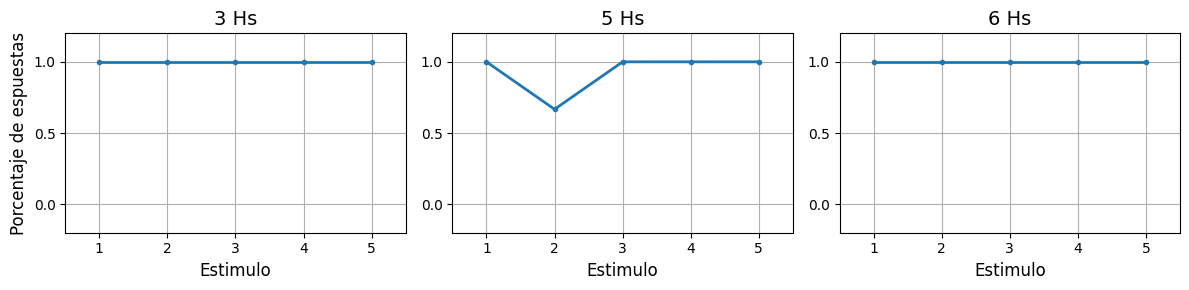

In [ ]:

estimulo = [1,2,3,4,5]
durante_3 = np.array([3,3,3,3,3])
durante_5 = np.array([3,2,3,3,3])
durante_6 = np.array([3,3,3,3,3])
post_3 = np.array([1,3,2,2,2])
post_5 = np.array([2,0,1,1,0])
post_6 = np.array([2,1,0,2,2])

d_3 = durante_3/3
d_5 = durante_5/3
d_6 = durante_6/3
p_3 = post_3/3
p_5 = post_5/3
p_6 = post_6/3


fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))

# Eventos 3hs
axs[0].plot(estimulo,d_3,'.-',lw=2, color='C0')
#axs[0].plot(estimulo,p_3,'.-',lw=2, color='C2')
# Eventos 5hs
axs[1].plot(estimulo,d_5,'.-',lw=2, color='C0',label='Durante')
#axs[1].plot(estimulo,p_5,'.-',lw=2, color='C2',label='Después')
#eventos 6hs
axs[2].plot(estimulo,d_6,'.-',lw=2, color='C0')
#axs[2].plot(estimulo,p_6,'.-',lw=2, color='C2')

#axs[1].legend(bbox_to_anchor=(3, 1))

# Ejes
axs[0].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,3))
axs[0].set_ylabel('Porcentaje de espuestas', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('3 Hs', fontsize=14)
axs[0].grid()

axs[1].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,3))
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('5 Hs', fontsize=14)
axs[1].grid()

axs[2].set(xlim=(0.5,5.5), xticks=np.arange(1, 6),ylim=(-0.2, 1.2),yticks=np.linspace(0, 1,3))
axs[2].set_xlabel('Estimulo', fontsize=12)
axs[2].set_title('6 Hs', fontsize=14)
axs[2].grid()

plt.tight_layout()
plt.show()

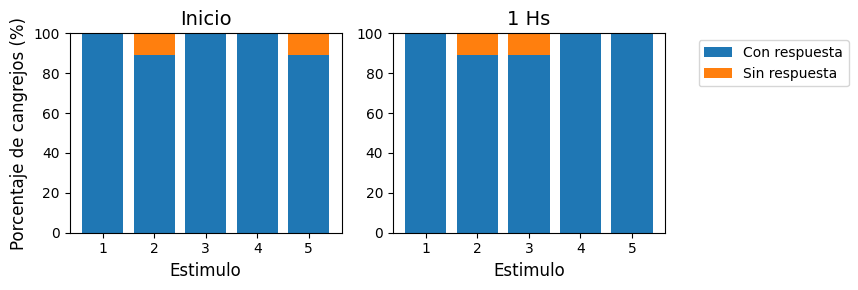

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
estimulo = [1, 2, 3, 4, 5]
cangrejo1 = [1, 1, 1, 1, 1]
cangrejo2 = [1, 1, 1, 1, 1]
cangrejo3 = [1, 1, 1, 1, 1]
cangrejo4 = [1, 1, 1, 1, 1]
cangrejo5 = [1, 1, 1, 1, 0]
cangrejo6 = [1, 0, 1, 1, 1]
cangrejo7 = [1, 1, 1, 1, 1]
cangrejo8 = [1, 1, 1, 1, 1]
cangrejo9 = [1, 1, 1, 1, 1]


fcangrejo1 = [1, 1, 1, 1, 1]
fcangrejo2 = [1, 1, 1, 1, 1]
fcangrejo3 = [1, 1, 1, 1, 1]
fcangrejo4 = [1, 1, 1, 1, 1]
fcangrejo5 = [1, 0, 0, 1, 1]
fcangrejo6 = [1, 1, 1, 1, 1]
fcangrejo7 = [1, 1, 1, 1, 1]
fcangrejo8 = [1, 1, 1, 1, 1]
fcangrejo9 = [1, 1, 1, 1, 1]

# Apilar respuestas
respuestas_inicio = np.array([cangrejo1, cangrejo2, cangrejo3,cangrejo4,cangrejo5,cangrejo6,cangrejo7,cangrejo8,cangrejo9])

# Calcular porcentaje de respuestas y no respuestas
total_cangrejos = respuestas_inicio.shape[0]
respuestas_porcentaje = np.sum(respuestas_inicio, axis=0) / total_cangrejos * 100
no_respuestas_porcentaje = 100 - respuestas_porcentaje


# Apilar respuestas
respuestas_final = np.array([fcangrejo1, fcangrejo2, fcangrejo3,fcangrejo4,fcangrejo5,fcangrejo6,fcangrejo7,fcangrejo8,fcangrejo9])

# Calcular porcentaje de respuestas y no respuestas
total_cangrejos_final = respuestas_final.shape[0]
respuestas_porcentaje_final = np.sum(respuestas_final, axis=0) / total_cangrejos_final * 100
no_respuestas_porcentaje_final = 100 - respuestas_porcentaje_final




fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(9, 3))

# Eventos inicio



axs[0].bar(estimulo, respuestas_porcentaje, label='Con respuesta', color='C0')
axs[0].bar(estimulo, no_respuestas_porcentaje, bottom=respuestas_porcentaje, label='Sin respuesta', color='C1')
# Eventos final
axs[1].bar(estimulo, respuestas_porcentaje_final, label='Con respuesta', color='C0')
axs[1].bar(estimulo, no_respuestas_porcentaje_final, bottom=respuestas_porcentaje_final, label='Sin respuesta', color='C1')



axs[1].legend(bbox_to_anchor=(1.7, 1))

# Ejes
axs[0].set(ylim=(0, 100))
axs[0].set_ylabel('Porcentaje de cangrejos (%)', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('Inicio', fontsize=14)
#axs[0].grid()
axs[1].set(ylim=(0, 100))
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('1 Hs', fontsize=14)

plt.tight_layout()
plt.show()





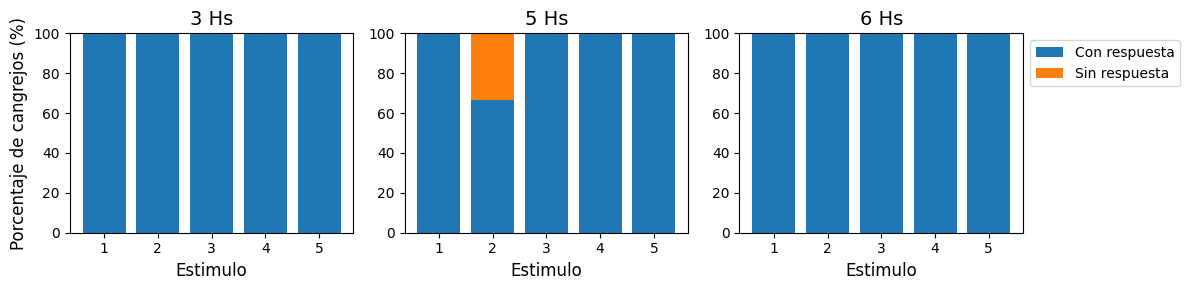

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
estimulo = [1, 2, 3, 4, 5]
cangrejo1 = [1, 1, 1, 1, 1]
cangrejo2 = [1, 1, 1, 1, 1]
cangrejo3 = [1, 1, 1, 1, 1]
cangrejo4 = [1, 1, 1, 1, 1]
cangrejo5 = [1, 0, 1, 1, 1]
cangrejo6 = [1, 1, 1, 1, 1]
cangrejo7 = [1, 1, 1, 1, 1]
cangrejo8 = [1, 1, 1, 1, 1]
cangrejo9 = [1, 1, 1, 1, 1]


# Apilar respuestas
respuestas_3 = np.array([cangrejo1, cangrejo2, cangrejo3])
respuestas_5 = np.array([cangrejo4,cangrejo5,cangrejo6])
respuestas_6 = np.array([cangrejo7,cangrejo8,cangrejo9])

# Calcular porcentaje de respuestas y no respuestas
total_cangrejos = respuestas_3.shape[0]


respuestas_porcentaje_3 = np.sum(respuestas_3, axis=0) / total_cangrejos * 100
no_respuestas_porcentaje_3 = 100 - respuestas_porcentaje_3

respuestas_porcentaje_5 = np.sum(respuestas_5, axis=0) / total_cangrejos * 100
no_respuestas_porcentaje_5 = 100 - respuestas_porcentaje_5

respuestas_porcentaje_6 = np.sum(respuestas_6, axis=0) / total_cangrejos * 100
no_respuestas_porcentaje_6 = 100 - respuestas_porcentaje_6


fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))

# Eventos inicio



axs[0].bar(estimulo, respuestas_porcentaje_3, label='Con respuesta', color='C0')
axs[0].bar(estimulo, no_respuestas_porcentaje_3, bottom=respuestas_porcentaje_3, label='Sin respuesta', color='C1')
# Eventos final
axs[1].bar(estimulo, respuestas_porcentaje_5, label='Con respuesta', color='C0')
axs[1].bar(estimulo, no_respuestas_porcentaje_5, bottom=respuestas_porcentaje_5, label='Sin respuesta', color='C1')

axs[2].bar(estimulo, respuestas_porcentaje_6, label='Con respuesta', color='C0')
axs[2].bar(estimulo, no_respuestas_porcentaje_6, bottom=respuestas_porcentaje_6, label='Sin respuesta', color='C1')

axs[3].bar(estimulo, respuestas_porcentaje_3, label='Con respuesta', color='C0')
axs[3].bar(estimulo, no_respuestas_porcentaje_3, bottom=respuestas_porcentaje_3, label='Sin respuesta', color='C1')
# Eventos final
axs[4].bar(estimulo, respuestas_porcentaje_5, label='Con respuesta', color='C0')
axs[4].bar(estimulo, no_respuestas_porcentaje_5, bottom=respuestas_porcentaje_5, label='Sin respuesta', color='C1')

axs[2].legend(bbox_to_anchor=(1, 1))

# Ejes
axs[0].set(ylim=(0, 100))
axs[0].set_ylabel('Porcentaje de cangrejos (%)', fontsize=12)
axs[0].set_xlabel('Estimulo', fontsize=12)
axs[0].set_title('3 Hs', fontsize=14)
#axs[0].grid()
axs[1].set(ylim=(0, 100))
axs[1].set_xlabel('Estimulo', fontsize=12)
axs[1].set_title('5 Hs', fontsize=14)

axs[2].set(ylim=(0, 100))
axs[2].set_xlabel('Estimulo', fontsize=12)
axs[2].set_title('6 Hs', fontsize=14)

plt.tight_layout()
plt.show()





In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos
tiempo = [1, 2, 3, 4, 5]
inicio = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0]
hora = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0]
hora_3 = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
hora_5 = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0]
hora_6 = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

# Apilar respuestas
respuestas = np.array([inicio, 1_hora, 3_hora,5_hora,6_hora])



# Calcular porcentaje de respuestas y no respuestas
total_cangrejos = respuestas.shape[0]
respuestas_porcentaje = np.sum(respuestas, axis=0) / total_cangrejos * 100
no_respuestas_porcentaje = 100 - respuestas_porcentaje

# Gráfico
plt.bar(estimulo, respuestas_porcentaje, label='Con respuesta', color='green')
plt.bar(estimulo, no_respuestas_porcentaje, bottom=respuestas_porcentaje, label='Sin respuesta', color='red')

plt.xlabel('')
plt.ylabel('Porcentaje de cangrejos (%)')
plt.legend()
plt.xticks(estimulo)
plt.ylim(0, 100)
plt.show()


SyntaxError: invalid decimal literal (ipython-input-39-3387547581.py, line 7)

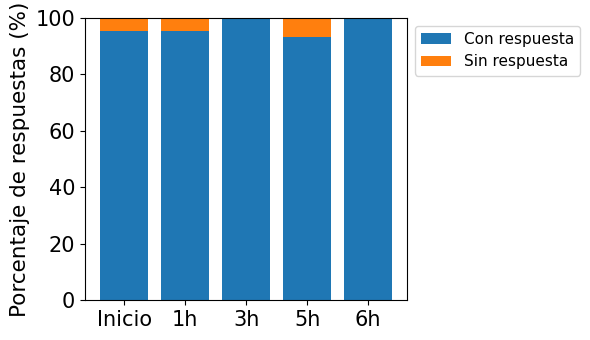

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de respuesta (1 = respuesta, 0 = sin respuesta)
inicio   = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0]
hora     = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0]
hora_3   = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]
hora_5   = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,0]
hora_6   = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

# Lista de momentos
momentos = ['Inicio', '1h', '3h', '5h', '6h']
respuestas_raw = [inicio, hora, hora_3, hora_5, hora_6]

# Cálculo de porcentajes de respuestas y no respuestas
respuestas_pct = []
no_respuestas_pct = []

for momento in respuestas_raw:
    total = len(momento)
    con_respuesta = sum(momento) / total * 100
    sin_respuesta = 100 - con_respuesta
    respuestas_pct.append(con_respuesta)
    no_respuestas_pct.append(sin_respuesta)

# Gráfico
x = np.arange(len(momentos))
plt.figure(figsize=(6, 3.5))
plt.bar(x, respuestas_pct, label='Con respuesta', color='C0')
plt.bar(x, no_respuestas_pct, bottom=respuestas_pct, label='Sin respuesta', color='C1')

plt.xticks(x, momentos, fontsize=15)
plt.yticks(fontsize=15)
plt.ylabel('Porcentaje de respuestas (%)', fontsize=15.5)
plt.ylim(0, 100)
plt.legend(bbox_to_anchor=(1, 1),fontsize=11)
plt.tight_layout()
plt.show()


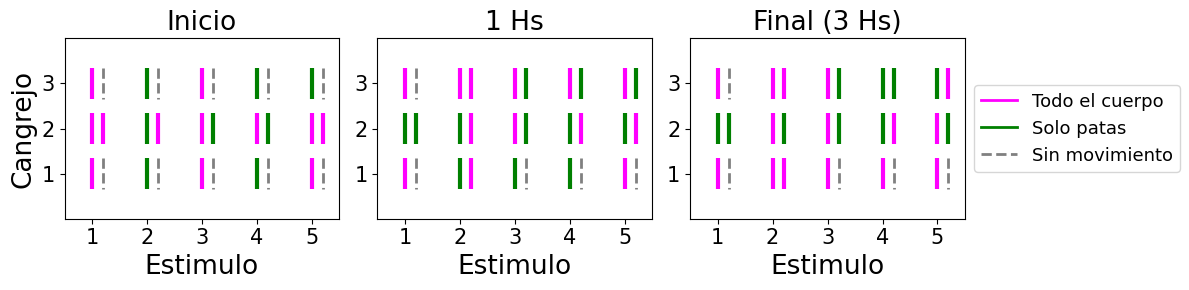

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

patas = 'green'
todo = 'magenta'
hueco = 'gray'

# Datos:
x = [1, 2, 3]
# Tiempo total (estimulo) en pasos de 1.0 y 0.1
tiempos_posibles = [1, 1.2, 2, 2.2, 3, 3.2, 4, 4.2, 5, 5.2]

D_patas_1 = [[2,4], [2], [2,4,5]]
D_todo_1  = [[1,3,5], [1,3,4,5], [1,3]]
P_patas_1 = [[], [3.2,4.2], []]
P_todo_1  = [[], [1.2,2.2,5.2], []]

D_patas_2 = [[2,3,4], [1,2,4,5], []]
D_todo_2  = [[1,5], [3], [1,2,3,4,5]]
P_patas_2 = [[], [1.2,3.2], [3.2,4.2,5.2]]
P_todo_2  = [[2.2], [2.2,4.2,5.2], [2.2]]

D_patas_3 = [[], [1,4], [4,5]]
D_todo_3  = [[1,2,3,4,5], [2,3,5], [1,2,3]]
P_patas_3 = [[], [1.2,2.2,3.2,5.2], [3.2,4.2]]
P_todo_3  = [[2.2], [4.2], [2.2,5.2]]

# Construir eventos totales por cangrejo
eventos_1 = []
for i in range(3):
    todos_eventos_1 = set(D_patas_1[i] + D_todo_1[i] + P_patas_1[i] + P_todo_1[i])
    vacios_1 = [t for t in tiempos_posibles if t not in todos_eventos_1]
    eventos_1.append(vacios_1)

eventos_2 = []
for i in range(3):
    todos_eventos_2 = set(D_patas_2[i] + D_todo_2[i] + P_patas_2[i] + P_todo_2[i])
    vacios_2 = [t for t in tiempos_posibles if t not in todos_eventos_2]
    eventos_2.append(vacios_2)

eventos_3 = []
for i in range(3):
    todos_eventos_3 = set(D_patas_3[i] + D_todo_3[i] + P_patas_3[i] + P_todo_3[i])
    vacios_3 = [t for t in tiempos_posibles if t not in todos_eventos_3]
    eventos_3.append(vacios_3)
l=3
a=0.7
# Plot:
fig, axs = plt.subplots(ncols=3, nrows=1, figsize=(12, 3))

# Eventos reales inicio
axs[0].eventplot(D_patas_1, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=patas)
axs[0].eventplot(P_patas_1, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=patas)
axs[0].eventplot(D_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=todo)
axs[0].eventplot(P_todo_1,  orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=todo)


# Eventos reales final
axs[1].eventplot(D_patas_2, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=patas)
axs[1].eventplot(P_patas_2, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=patas)
axs[1].eventplot(D_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=todo)
axs[1].eventplot(P_todo_2,  orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=todo)

axs[2].eventplot(D_patas_3, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=patas)
axs[2].eventplot(P_patas_3, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=patas)
axs[2].eventplot(D_todo_3,  orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=todo)
axs[2].eventplot(P_todo_3,  orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=l, color=todo)

# Eventos vacíos (huecos)
axs[0].eventplot(eventos_1, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=2, color=hueco,linestyles='--')
# Eventos vacíos (huecos)
axs[1].eventplot(eventos_2, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=2, color=hueco,linestyles='--')
axs[2].eventplot(eventos_3, orientation="horizontal", lineoffsets=x, linelengths=a, linewidth=2, color=hueco,linestyles='--')

# Leyenda
legend_elements = [
    Line2D([0], [0], color=todo, lw=2, label='Todo el cuerpo'),
    Line2D([0], [0], color=patas, lw=2, label='Solo patas'),
    Line2D([0], [0],ls='--', color=hueco, lw=2, label='Sin movimiento')
]


#axs[0].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))
axs[2].legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5),fontsize=13)

# Ejes
axs[0].set(xlim=(0.5, 5.5), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[0].tick_params(axis='both', labelsize=15)
axs[0].set_ylabel('Cangrejo', fontsize=19)
axs[0].set_xlabel('Estimulo', fontsize=19)
axs[0].set_title('Inicio', fontsize=19)

axs[1].set(xlim=(0.5, 5.5), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[1].tick_params(axis='both', labelsize=15)
#axs[1].set_ylabel('Cangrejo', fontsize=10)
axs[1].set_xlabel('Estimulo', fontsize=19)
axs[1].set_title('1 Hs', fontsize=19)

axs[2].set(xlim=(0.5, 5.5), xticks=np.arange(1, 6),ylim=(0, 4), yticks=np.arange(1, 4))
axs[2].tick_params(axis='both', labelsize=15)
#axs[2].set_ylabel('Cangrejo', fontsize=10)
axs[2].set_xlabel('Estimulo', fontsize=19)
axs[2].set_title('Final (3 Hs)', fontsize=19)

plt.tight_layout()
plt.show()
